# 2차원 Fourier Transform

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from PIL import Image

In [2]:
IMAGE_PATH = "images/Blue_Marble_2002.png"
image = Image.open(IMAGE_PATH)
image = image.resize((128,128))
image_arr = np.array(image.convert('RGB'))
print(image_arr.shape)

(128, 128, 3)


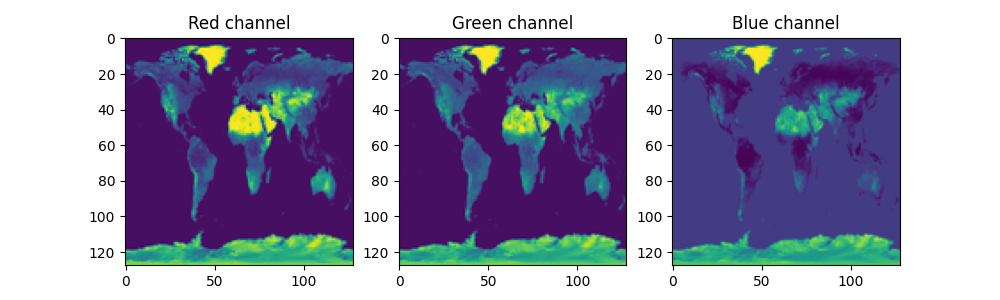

In [3]:
fig, ax_rgb = plt.subplots(1,3,figsize=(10,3))
title = ["Red channel","Green channel", "Blue channel"]
for i in range(3):
    ax_rgb[i].imshow(image_arr[...,i])
    ax_rgb[i].set_title(title[i])

plt.show()

In [4]:
R = image_arr[...,0]
H = R.shape[0]
W = R.shape[1]
print(f"H : {H}, W : {W}")

r_mid_line = R[H//2]
print(r_mid_line.shape)

H : 128, W : 128
(128,)


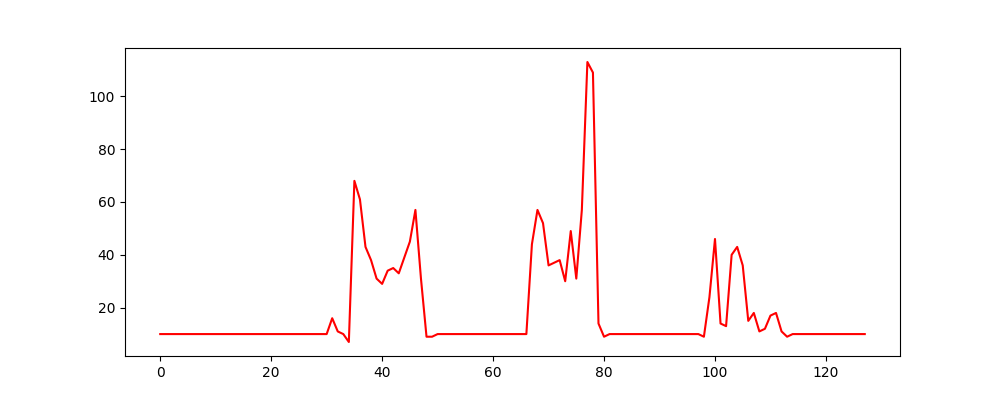

In [5]:
fig_r, ax_r = plt.subplots(1,1,figsize=(10,4))

x = np.arange(W)
y = r_mid_line

ax_r.plot(x,y, color='r')
plt.show()

In [6]:
def ifft(fft_x, n):
    
    filtered_x = np.zeros_like(fft_x)

    keep = [0]
    for i in range(1,n+1):
        keep.extend([i,-i])

    for i in keep:
        filtered_x[i] = fft_x[i]

    return np.fft.ifft(filtered_x)

In [7]:
fft_x = np.fft.fft(r_mid_line)
n = 30
ifft_x = ifft(fft_x, n)

c:\Users\son97\gaussian_splatting\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\son97\gaussian_splatting\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


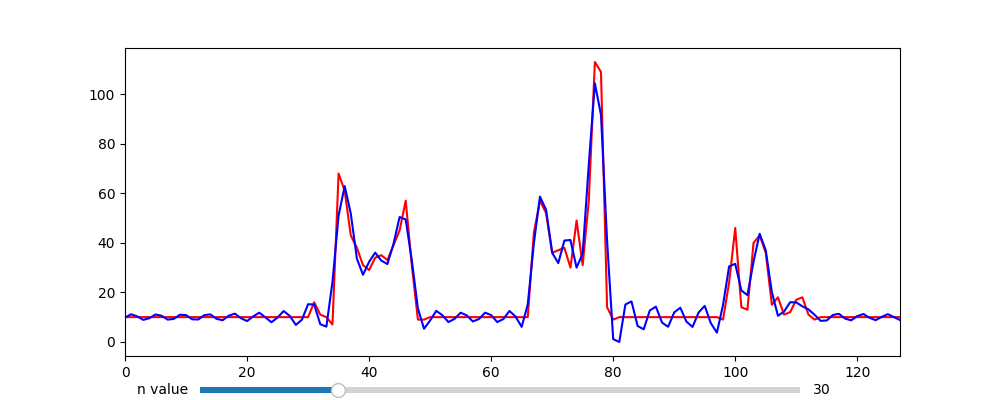

In [8]:
fig_fft, ax_fft = plt.subplots(1,1,figsize=(10,4))

x = np.arange(W)
y = r_mid_line
ax_fft.set_xlim([0,W-1])

ax_fft.plot(x,y, color='r')
fft_graph, = ax_fft.plot(x,ifft_x, color='b')

axes = plt.axes([0.2, 0.01,0.6, 0.03])
n_slider = Slider(axes, label="n value",valmin=1, valmax=W-1, valinit=n)

def update(x):
    n = int(n_slider.val)
    fft_graph.set_ydata(ifft(fft_x, n))

    fig_fft.canvas.draw_idle()

n_slider.on_changed(update)
plt.show()